# Exploratory Data Analysis: GDP per Capita vs. Internet Usage (2000–2022)

In [9]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


In [ ]:
internet_usage = pd.read_csv("data/internet_usage.csv", skiprows=1)
gdp = pd.read_csv("data/gdp_per_capita.csv", skiprows=4)
region_income = pd.read_csv("data/country_metadata.csv")

### Data Inspection

In [11]:
internet_usage.columns = ["Country Code", "Region/Country/Area", "Year", "Series", "Value", "Footnotes", "Source"]
internet_usage.info()
internet_usage.head()
internet_usage.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1552 entries, 0 to 1551
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Country Code         1552 non-null   int64  
 1   Region/Country/Area  1552 non-null   object 
 2   Year                 1552 non-null   int64  
 3   Series               1552 non-null   object 
 4   Value                1552 non-null   float64
 5   Footnotes            1033 non-null   object 
 6   Source               1552 non-null   object 
dtypes: float64(1), int64(2), object(4)
memory usage: 85.0+ KB


,Country Code,Region/Country/Area,Year,Series,Value,Footnotes,Source
0,1,"Total, all countries or areas",2000,Percentage of individuals using the internet,5.3,NaN,"International Telecommunication Union (ITU), G..."
1,1,"Total, all countries or areas",2005,Percentage of individuals using the internet,15.6,NaN,"International Telecommunication Union (ITU), G..."
2,1,"Total, all countries or areas",2010,Percentage of individuals using the internet,28.5,NaN,"International Telecommunication Union (ITU), G..."
3,1,"Total, all countries or areas",2015,Percentage of individuals using the internet,39.9,NaN,"International Telecommunication Union (ITU), G..."
4,1,"Total, all countries or areas",2020,Percentage of individuals using the internet,59.3,NaN,"International Telecommunication Union (ITU), G..."


,Country Code,Region/Country/Area,Year,Series,Value,Footnotes,Source
1547,722,SIDS,2010,Percentage of individuals using the internet,22.2,NaN,"International Telecommunication Union (ITU), G..."
1548,722,SIDS,2015,Percentage of individuals using the internet,36.3,NaN,"International Telecommunication Union (ITU), G..."
1549,722,SIDS,2020,Percentage of individuals using the internet,61.3,NaN,"International Telecommunication Union (ITU), G..."
1550,722,SIDS,2021,Percentage of individuals using the internet,63.6,NaN,"International Telecommunication Union (ITU), G..."
1551,722,SIDS,2022,Percentage of individuals using the internet,65.0,NaN,"International Telecommunication Union (ITU), G..."


In [12]:
gdp.info()
gdp.head()
gdp.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 70 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            151 non-null    float64
 5   1961            154 non-null    float64
 6   1962            156 non-null    float64
 7   1963            156 non-null    float64
 8   1964            156 non-null    float64
 9   1965            162 non-null    float64
 10  1966            163 non-null    float64
 11  1967            167 non-null    float64
 12  1968            168 non-null    float64
 13  1969            168 non-null    float64
 14  1970            190 non-null    float64
 15  1971            191 non-null    float64
 16  1972            191 non-null    float64
 17  1973            191 non-null    flo

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,27441.529662,28440.051964,30082.127645,31096.205074,22855.932320,27200.061079,30559.533535,33984.790620,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,186.121835,186.941781,197.402402,225.440494,208.999748,226.876513,...,1329.807285,1520.212231,1538.901679,1493.817938,1344.103210,1522.393346,1628.318944,1510.742951,1567.635839,NaN
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,522.082216,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,NaN,NaN
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,121.939925,127.454189,133.827044,139.008291,148.549379,155.565216,...,1630.039447,1574.230560,1720.140280,1798.340685,1680.039332,1765.954788,1796.668633,1599.392983,1284.154441,NaN
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,1807.952941,2437.259712,2538.591391,2189.855714,1449.922867,1925.874661,2929.694455,2309.534130,2122.083690,NaN


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
261,Kosovo,XKX,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,3759.449591,4009.317993,4384.186241,4415.997161,4310.890655,5270.429653,5290.947472,6221.203652,7299.434981,NaN
262,"Yemen, Rep.",YEM,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,975.359417,811.165970,633.887202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
263,South Africa,ZAF,GDP per capita (current US$),NY.GDP.PCAP.CD,532.147504,545.657512,563.423009,604.536855,645.873376,684.621228,...,5651.205852,6618.335083,6914.178032,6533.711210,5580.603831,6843.399419,6523.410978,6022.542542,6253.371582,NaN
264,Zambia,ZMB,GDP per capita (current US$),NY.GDP.PCAP.CD,221.559849,209.693206,202.281031,203.219451,229.979246,287.425476,...,1239.085279,1483.465773,1463.899979,1258.986198,951.644317,1127.160779,1447.123101,1330.727806,1235.084665,NaN
265,Zimbabwe,ZWE,GDP per capita (current US$),NY.GDP.PCAP.CD,276.419784,279.016489,275.545608,277.005701,281.744539,294.145359,...,1407.420964,3448.086991,2271.852504,1683.913136,1730.453910,1724.387271,2040.546587,2156.034093,2656.409377,NaN


In [13]:
region_income.info()
region_income.head()
region_income.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Code  265 non-null    object 
 1   Region        217 non-null    object 
 2   IncomeGroup   215 non-null    object 
 3   SpecialNotes  130 non-null    object 
 4   TableName     265 non-null    object 
 5   Unnamed: 5    0 non-null      float64
dtypes: float64(1), object(5)
memory usage: 12.6+ KB


,Country Code,Region,IncomeGroup,SpecialNotes,TableName,Unnamed: 5
0,ABW,Latin America & Caribbean,High income,NaN,Aruba,NaN
1,AFE,NaN,NaN,"26 countries, stretching from the Red Sea in t...",Africa Eastern and Southern,NaN
2,AFG,Middle East & North Africa,Low income,The reporting period for national accounts dat...,Afghanistan,NaN
3,AFW,NaN,NaN,"22 countries, stretching from the westernmost ...",Africa Western and Central,NaN
4,AGO,Sub-Saharan Africa,Lower middle income,The World Bank systematically assesses the app...,Angola,NaN


,Country Code,Region,IncomeGroup,SpecialNotes,TableName,Unnamed: 5
260,XKX,Europe & Central Asia,Upper middle income,NaN,Kosovo,NaN
261,YEM,Middle East & North Africa,Low income,The World Bank systematically assesses the app...,"Yemen, Rep.",NaN
262,ZAF,Sub-Saharan Africa,Upper middle income,Fiscal year end: March 31; reporting period fo...,South Africa,NaN
263,ZMB,Sub-Saharan Africa,Lower middle income,National accounts data were rebased to reflect...,Zambia,NaN
264,ZWE,Sub-Saharan Africa,Lower middle income,National Accounts data are reported in Zimbabw...,Zimbabwe,NaN


We can see that there are no repeats of country names in "TableName" as the length is 265, which is the RangeIndex of the dataframe. 

In [7]:
region_income.value_counts(["Region"])
region_income.value_counts(["IncomeGroup"])
region_income.value_counts(["TableName"])

Region                    
Europe & Central Asia         58
Sub-Saharan Africa            48
Latin America & Caribbean     42
East Asia & Pacific           37
Middle East & North Africa    23
South Asia                     6
North America                  3
Name: count, dtype: int64

IncomeGroup        
High income            86
Upper middle income    54
Lower middle income    50
Low income             25
Name: count, dtype: int64

TableName    
Afghanistan      1
Norway           1
Mozambique       1
Myanmar          1
Namibia          1
                ..
Guam             1
Guatemala        1
Guinea           1
Guinea-Bissau    1
Zimbabwe         1
Name: count, Length: 265, dtype: int64

As seen below, all of the nulls for Region are for not for countries but for larger regions, most of which will not be used in my analysis, since I will conduct an inner-merge. The only countries that have nulls for "IncomeGroup" are Venezuala, RB and Ethiopia.

In [8]:
region_income[region_income["Region"].isnull()]
region_income[region_income["IncomeGroup"].isnull()]

,Country Code,Region,IncomeGroup,SpecialNotes,TableName,Unnamed: 5
1,AFE,NaN,NaN,"26 countries, stretching from the Red Sea in t...",Africa Eastern and Southern,NaN
3,AFW,NaN,NaN,"22 countries, stretching from the westernmost ...",Africa Western and Central,NaN
7,ARB,NaN,NaN,Arab World aggregate. Arab World is composed o...,Arab World,NaN
36,CEB,NaN,NaN,Central Europe and the Baltics aggregate.,Central Europe and the Baltics,NaN
49,CSS,NaN,NaN,Caribbean small states aggregate.,Caribbean small states,NaN
61,EAP,NaN,NaN,NaN,East Asia & Pacific (excluding high income),NaN
62,EAR,NaN,NaN,Early-dividend countries are mostly lower-midd...,Early-demographic dividend,NaN
63,EAS,NaN,NaN,East Asia and Pacific regional aggregate (incl...,East Asia & Pacific,NaN
64,ECA,NaN,NaN,NaN,Europe & Central Asia (excluding high income),NaN
65,ECS,NaN,NaN,Europe and Central Asia regional aggregate (in...,Europe & Central Asia,NaN


,Country Code,Region,IncomeGroup,SpecialNotes,TableName,Unnamed: 5
1,AFE,NaN,NaN,"26 countries, stretching from the Red Sea in t...",Africa Eastern and Southern,NaN
3,AFW,NaN,NaN,"22 countries, stretching from the westernmost ...",Africa Western and Central,NaN
7,ARB,NaN,NaN,Arab World aggregate. Arab World is composed o...,Arab World,NaN
36,CEB,NaN,NaN,Central Europe and the Baltics aggregate.,Central Europe and the Baltics,NaN
49,CSS,NaN,NaN,Caribbean small states aggregate.,Caribbean small states,NaN
61,EAP,NaN,NaN,NaN,East Asia & Pacific (excluding high income),NaN
62,EAR,NaN,NaN,Early-dividend countries are mostly lower-midd...,Early-demographic dividend,NaN
63,EAS,NaN,NaN,East Asia and Pacific regional aggregate (incl...,East Asia & Pacific,NaN
64,ECA,NaN,NaN,NaN,Europe & Central Asia (excluding high income),NaN
65,ECS,NaN,NaN,Europe and Central Asia regional aggregate (in...,Europe & Central Asia,NaN


I will only be looking at data from these following years: 2000, 2005, 2010, 2015, 2020, 2021, 2022. We can see from using value_counts() that there are no repeats of country name in for GDP. However, we do see a handful of nulls for the year columns that we will be using. An inspection of the data from the years in question using df.describe() shows that there are no min values of zero for GDP per capita for any years, and the data looks normal.

In [9]:
gdp.info()
gdp.value_counts(["Country Name"])
gdp[["2000", "2005", "2010", "2015", "2020", "2021", "2022"]].describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 70 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            151 non-null    float64
 5   1961            154 non-null    float64
 6   1962            156 non-null    float64
 7   1963            156 non-null    float64
 8   1964            156 non-null    float64
 9   1965            162 non-null    float64
 10  1966            163 non-null    float64
 11  1967            167 non-null    float64
 12  1968            168 non-null    float64
 13  1969            168 non-null    float64
 14  1970            190 non-null    float64
 15  1971            191 non-null    float64
 16  1972            191 non-null    float64
 17  1973            191 non-null    flo

Country Name 
Afghanistan      1
Norway           1
Mozambique       1
Myanmar          1
Namibia          1
                ..
Guam             1
Guatemala        1
Guinea           1
Guinea-Bissau    1
Zimbabwe         1
Name: count, Length: 266, dtype: int64

,2000,2005,2010,2015,2020,2021,2022
count,252.000000,257.000000,261.000000,259.000000,257.000000,257.000000,256.000000
mean,7559.367219,11572.806477,15027.998842,15670.547829,16317.309558,18841.655933,19495.394383
std,12207.027192,18207.596636,22601.269256,23570.955343,24347.915625,28826.962336,28997.997428
min,122.269203,147.234619,216.727705,280.966831,210.008140,214.091455,250.634225
25%,635.427311,1067.920606,1663.966937,1996.657596,2081.739142,2445.186625,2388.573827
50%,1817.635309,3146.826074,5418.216334,6141.203947,6236.681205,7051.202111,7630.915868
75%,8377.655117,14368.570880,19847.231013,19060.625424,19966.483850,22132.448303,23994.445832
max,81789.020652,130538.742587,161853.920622,170437.101188,176891.886538,223823.363960,226052.001905


Outliers for GDP per capita have stayed consistent over the years. Lichtenstein and Monaco have had GDP per capita over 100000 since 2005, and they've been the two biggest outliers every year since then for the years being studied. 

<Axes: >

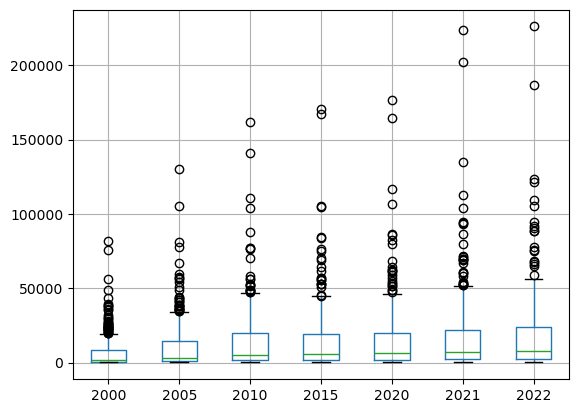

,Country Name,2000,2005,2010,2015,2020,2021,2022
27,Bermuda,56542.956946,77628.103523,104111.824245,104855.366822,106976.546240,112765.081673,121613.939984
111,Ireland,26334.567205,50933.021610,48679.402682,64311.823468,86622.506725,103961.976351,105234.511568
137,Liechtenstein,76087.911114,105295.057028,141089.812849,167187.157310,164671.093553,201944.830335,186821.881757
144,Luxembourg,48659.598875,80988.137623,110885.991379,105462.012584,116860.028172,134965.815442,123719.658916
149,Monaco,81789.020652,130538.742587,161853.920622,170437.101188,176891.886538,223823.363960,226052.001905
177,Norway,38178.236878,67047.170456,88163.208593,74809.965805,68340.018103,93072.892512,109269.520580


In [10]:
gdp[["2000", "2005", "2010", "2015", "2020", "2021", "2022"]].boxplot()
plt.show();
outliers = gdp[(gdp[["2000", "2005", "2010", "2015", "2020", "2021", "2022"]] >= 100000).any(axis=1)]
outliers[["Country Name", "2000", "2005", "2010", "2015", "2020", "2021", "2022"]]


Internet_usage looks quite clean. The only columns I will be using are "Region/Country/Area", "Year", and  "Value." "Value" gives the percent of internet users.

In [11]:
internet_usage.info()
internet_usage.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1552 entries, 0 to 1551
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Country Code         1552 non-null   int64  
 1   Region/Country/Area  1552 non-null   object 
 2   Year                 1552 non-null   int64  
 3   Series               1552 non-null   object 
 4   Value                1552 non-null   float64
 5   Footnotes            1033 non-null   object 
 6   Source               1552 non-null   object 
dtypes: float64(1), int64(2), object(4)
memory usage: 85.0+ KB


,Country Code,Region/Country/Area,Year,Series,Value,Footnotes,Source
0,1,"Total, all countries or areas",2000,Percentage of individuals using the internet,5.3,NaN,"International Telecommunication Union (ITU), G..."
1,1,"Total, all countries or areas",2005,Percentage of individuals using the internet,15.6,NaN,"International Telecommunication Union (ITU), G..."
2,1,"Total, all countries or areas",2010,Percentage of individuals using the internet,28.5,NaN,"International Telecommunication Union (ITU), G..."
3,1,"Total, all countries or areas",2015,Percentage of individuals using the internet,39.9,NaN,"International Telecommunication Union (ITU), G..."
4,1,"Total, all countries or areas",2020,Percentage of individuals using the internet,59.3,NaN,"International Telecommunication Union (ITU), G..."


In [12]:
internet_usage.value_counts(["Region/Country/Area"])
internet_usage["Value"].describe()
internet_usage[internet_usage['Value'] == 100]
internet_usage[internet_usage['Value'] == 0]

Region/Country/Area        
Lebanon                        7
Mauritius                      7
Micronesia                     7
Middle Africa                  7
Monaco                         7
                              ..
Réunion                        2
Mayotte                        1
Serbia and Monten. [former]    1
Montserrat                     1
British Virgin Islands         1
Name: count, Length: 247, dtype: int64

count    1552.000000
mean       43.969588
std        33.044143
min         0.000000
25%        10.500000
50%        40.050000
75%        75.325000
max       100.000000
Name: Value, dtype: float64

,Country Code,Region/Country/Area,Year,Series,Value,Footnotes,Source
232,48,Bahrain,2021,Percentage of individuals using the internet,100.0,Population aged 15 years and over.,"International Telecommunication Union (ITU), G..."
233,48,Bahrain,2022,Percentage of individuals using the internet,100.0,Population aged 15 years and over.,"International Telecommunication Union (ITU), G..."
1153,634,Qatar,2021,Percentage of individuals using the internet,100.0,Data revision.;Population aged 15 years and over.,"International Telecommunication Union (ITU), G..."
1154,634,Qatar,2022,Percentage of individuals using the internet,100.0,Data revision.;Population aged 15 years and over.,"International Telecommunication Union (ITU), G..."
1242,682,Saudi Arabia,2021,Percentage of individuals using the internet,100.0,Population aged 10 to 74 years.,"International Telecommunication Union (ITU), G..."
1243,682,Saudi Arabia,2022,Percentage of individuals using the internet,100.0,Population aged 15 to 74 years.,"International Telecommunication Union (ITU), G..."
1447,784,United Arab Emirates,2020,Percentage of individuals using the internet,100.0,Population aged 15 to 74 years.,"International Telecommunication Union (ITU), G..."
1448,784,United Arab Emirates,2021,Percentage of individuals using the internet,100.0,Population aged 15 to 74 years.,"International Telecommunication Union (ITU), G..."
1449,784,United Arab Emirates,2022,Percentage of individuals using the internet,100.0,Population aged 15 to 74 years.,"International Telecommunication Union (ITU), G..."


,Country Code,Region/Country/Area,Year,Series,Value,Footnotes,Source
350,116,Cambodia,2000,Percentage of individuals using the internet,0.0,NaN,"International Telecommunication Union (ITU), G..."
378,148,Chad,2000,Percentage of individuals using the internet,0.0,NaN,"International Telecommunication Union (ITU), G..."
424,178,Congo,2000,Percentage of individuals using the internet,0.0,NaN,"International Telecommunication Union (ITU), G..."
477,408,Dem. People's Rep. Korea,2000,Percentage of individuals using the internet,0.0,Commercially not available. Local Intranet ava...,"International Telecommunication Union (ITU), G..."
478,408,Dem. People's Rep. Korea,2005,Percentage of individuals using the internet,0.0,Commercially not available. Local Intranet ava...,"International Telecommunication Union (ITU), G..."
479,408,Dem. People's Rep. Korea,2010,Percentage of individuals using the internet,0.0,Data revision.,"International Telecommunication Union (ITU), G..."
480,180,Dem. Rep. of the Congo,2000,Percentage of individuals using the internet,0.0,NaN,"International Telecommunication Union (ITU), G..."
563,231,Ethiopia,2000,Percentage of individuals using the internet,0.0,NaN,"International Telecommunication Union (ITU), G..."
858,430,Liberia,2000,Percentage of individuals using the internet,0.0,NaN,"International Telecommunication Union (ITU), G..."
1043,562,Niger,2000,Percentage of individuals using the internet,0.0,NaN,"International Telecommunication Union (ITU), G..."


### Data Cleaning

I renamed columns in region_income for clarity and consistency when merging, selected relevant variables, and removed irrelevant fields. 

In [13]:
region_income.info()
region_income = region_income.rename(columns={'IncomeGroup': 'Income Group',
 'TableName': 'Country/Territory Name'})
region_income = region_income[["Region", "Income Group", "Country/Territory Name"]]
region_income.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Code  265 non-null    object 
 1   Region        217 non-null    object 
 2   IncomeGroup   215 non-null    object 
 3   SpecialNotes  130 non-null    object 
 4   TableName     265 non-null    object 
 5   Unnamed: 5    0 non-null      float64
dtypes: float64(1), object(5)
memory usage: 12.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Region                  217 non-null    object
 1   Income Group            215 non-null    object
 2   Country/Territory Name  265 non-null    object
dtypes: object(3)
memory usage: 6.3+ KB


I selected relevant columns for GDP per capita data aligned with internet usage data and standardized column names.

In [14]:
gdp.info()
gdp_1 = gdp[["Country Name", "2000", "2005", "2010", "2015", "2020", "2021", "2022"]]
gdp_1 = gdp_1.rename(columns = {"Country Name": "Country/Territory Name"})
gdp_1.info()
gdp_1.head()
gdp_1.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 70 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            151 non-null    float64
 5   1961            154 non-null    float64
 6   1962            156 non-null    float64
 7   1963            156 non-null    float64
 8   1964            156 non-null    float64
 9   1965            162 non-null    float64
 10  1966            163 non-null    float64
 11  1967            167 non-null    float64
 12  1968            168 non-null    float64
 13  1969            168 non-null    float64
 14  1970            190 non-null    float64
 15  1971            191 non-null    float64
 16  1972            191 non-null    float64
 17  1973            191 non-null    flo

,Country/Territory Name,2000,2005,2010,2015,2020,2021,2022
0,Aruba,20681.023027,24171.837133,24093.140151,27458.225331,22855.932320,27200.061079,30559.533535
1,Africa Eastern and Southern,707.120378,1115.713957,1601.727651,1479.615260,1344.103210,1522.393346,1628.318944
2,Afghanistan,174.930991,254.184249,560.621505,565.569730,510.787063,356.496214,357.261153
3,Africa Western and Central,516.932316,1001.604607,1663.966937,1860.727694,1680.039332,1765.954788,1796.668633
4,Angola,563.733796,1916.468422,3597.342932,3213.902611,1449.922867,1925.874661,2929.694455


,Country/Territory Name,2000,2005,2010,2015,2020,2021,2022
261,Kosovo,NaN,NaN,2987.545196,3520.628507,4310.890655,5270.429653,5290.947472
262,"Yemen, Rep.",493.235183,734.159908,1155.203053,1362.173812,NaN,NaN,NaN
263,South Africa,3217.846934,5836.876633,7973.471958,6112.273825,5580.603831,6843.399419,6523.410978
264,Zambia,359.429501,710.982068,1451.106160,1295.877887,951.644317,1127.160779,1447.123101
265,Zimbabwe,562.556946,461.028318,901.550518,1386.418559,1730.453910,1724.387271,2040.546587


I converted the gdp_1 dataframe from wide form to long form.

In [15]:
gdp_1.info()
col = gdp_1.columns[1:]
gdp_1 = (pd.melt(gdp_1, id_vars = ["Country/Territory Name"], value_vars = col, var_name = "Year", value_name = "GDP Per Capita"))
gdp_1.info()
gdp_1.head()
gdp_1.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Territory Name  266 non-null    object 
 1   2000                    252 non-null    float64
 2   2005                    257 non-null    float64
 3   2010                    261 non-null    float64
 4   2015                    259 non-null    float64
 5   2020                    257 non-null    float64
 6   2021                    257 non-null    float64
 7   2022                    256 non-null    float64
dtypes: float64(7), object(1)
memory usage: 16.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1862 entries, 0 to 1861
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Territory Name  1862 non-null   object 
 1   Year                    1862 non-null   obj

,Country/Territory Name,Year,GDP Per Capita
0,Aruba,2000,20681.023027
1,Africa Eastern and Southern,2000,707.120378
2,Afghanistan,2000,174.930991
3,Africa Western and Central,2000,516.932316
4,Angola,2000,563.733796


,Country/Territory Name,Year,GDP Per Capita
1857,Kosovo,2022,5290.947472
1858,"Yemen, Rep.",2022,NaN
1859,South Africa,2022,6523.410978
1860,Zambia,2022,1447.123101
1861,Zimbabwe,2022,2040.546587


Here, I converted the "Year" column in gdp_1 from an object to an int64 datatype.

In [16]:
gdp_1.info()
gdp_1["Year"]= gdp_1["Year"].astype(int)
gdp_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1862 entries, 0 to 1861
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Territory Name  1862 non-null   object 
 1   Year                    1862 non-null   object 
 2   GDP Per Capita          1799 non-null   float64
dtypes: float64(1), object(2)
memory usage: 43.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1862 entries, 0 to 1861
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Territory Name  1862 non-null   object 
 1   Year                    1862 non-null   int64  
 2   GDP Per Capita          1799 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 43.8+ KB


Again, I renamed and standardized columns in internet_usage for consistency in merging. I selected analysis-relevant fields from internet_usage and removed unessential fields. 

In [17]:
internet_usage.info()
internet_usage = internet_usage.rename(columns={'Region/Country/Area': 'Country/Territory Name', 'Value': "Percentage of Individuals Using the Internet"})
internet_usage = internet_usage[["Country/Territory Name", "Year", "Percentage of Individuals Using the Internet"]]
internet_usage.info()
internet_usage.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1552 entries, 0 to 1551
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Country Code         1552 non-null   int64  
 1   Region/Country/Area  1552 non-null   object 
 2   Year                 1552 non-null   int64  
 3   Series               1552 non-null   object 
 4   Value                1552 non-null   float64
 5   Footnotes            1033 non-null   object 
 6   Source               1552 non-null   object 
dtypes: float64(1), int64(2), object(4)
memory usage: 85.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1552 entries, 0 to 1551
Data columns (total 3 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Country/Territory Name                        1552 non-null   object 
 1   Year                                         

,Country/Territory Name,Year,Percentage of Individuals Using the Internet
0,"Total, all countries or areas",2000,5.3
1,"Total, all countries or areas",2005,15.6
2,"Total, all countries or areas",2010,28.5
3,"Total, all countries or areas",2015,39.9
4,"Total, all countries or areas",2020,59.3


I standardized country names across datasets for merge consistency and verified changes before and after standardization.

In [18]:
internet_usage_original = internet_usage["Country/Territory Name"].copy()


internet_usage["Country/Territory Name"] = internet_usage["Country/Territory Name"].replace({"Bahamas": "Bahamas, The","Bolivia (Plurin. State of)": "Bolivia",
"Côte d’Ivoire": "Cote d'Ivoire", "Dem. Rep. of the Congo": "Congo, Dem. Rep.","Congo": "Congo, Rep.","Egypt": "Egypt, Arab Rep.", "Micronesia": "Micronesia, Fed. Sts.",
"Gambia": "Gambia, The","China, Hong Kong SAR": "Hong Kong SAR, China","Iran (Islamic Republic of)": "Iran, Islamic Rep.", "Kyrgyzstan": "Kyrgyz Republic",
"Saint Kitts and Nevis":"St. Kitts and Nevis", "Republic of Korea":"Korea, Rep.", "Lao People's Dem. Rep.": "Lao PDR","Saint Lucia": "St. Lucia","China, Macao SAR": "Macao SAR, China",
"Netherlands (Kingdom of the)": "Netherlands","Puerto Rico": "Puerto Rico (US)","State of Palestine": "West Bank and Gaza","Somalia": "Somalia, Fed. Rep.",
"Slovakia": "Slovak Republic", "Türkiye": "Turkiye", "United Rep. of Tanzania": "Tanzania", "United States of America": "United States",
"Saint Vincent & Grenadines": "St. Vincent and the Grenadines","Venezuela (Boliv. Rep. of)": "Venezuela, RB", "United States Virgin Islands": "Virgin Islands (U.S.)",
"Yemen": "Yemen, Rep.","Total, all countries or areas": "World"})

internet_usage_original.compare(internet_usage["Country/Territory Name"])


,self,other
0,"Total, all countries or areas",World
1,"Total, all countries or areas",World
2,"Total, all countries or areas",World
3,"Total, all countries or areas",World
4,"Total, all countries or areas",World
...,...,...
1512,Yemen,"Yemen, Rep."
1513,Yemen,"Yemen, Rep."
1514,Yemen,"Yemen, Rep."
1515,Yemen,"Yemen, Rep."


I did an inner merge between gdp_1 and internet_usage on 'Country/Territory Name' and 'Year' to create a new dataframe called combined_df.

In [19]:
combined_df = pd.merge(gdp_1, internet_usage, on=['Country/Territory Name', 'Year'], how='inner')
combined_df.info()
combined_df.head()
combined_df.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1355 entries, 0 to 1354
Data columns (total 4 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Country/Territory Name                        1355 non-null   object 
 1   Year                                          1355 non-null   int64  
 2   GDP Per Capita                                1335 non-null   float64
 3   Percentage of Individuals Using the Internet  1355 non-null   float64
dtypes: float64(2), int64(1), object(1)
memory usage: 42.5+ KB


,Country/Territory Name,Year,GDP Per Capita,Percentage of Individuals Using the Internet
0,Aruba,2000,20681.023027,15.4
1,Angola,2000,563.733796,0.1
2,Albania,2000,1160.420471,0.1
3,Andorra,2000,21810.248743,10.5
4,United Arab Emirates,2000,29865.502347,23.6


,Country/Territory Name,Year,GDP Per Capita,Percentage of Individuals Using the Internet
1350,Samoa,2022,3869.466395,75.3
1351,"Yemen, Rep.",2022,NaN,17.7
1352,South Africa,2022,6523.410978,74.7
1353,Zambia,2022,1447.123101,31.2
1354,Zimbabwe,2022,2040.546587,32.6


I did a left merge between combined_df and region_income on "Country/Territory Name." 

In [20]:
combined_df = pd.merge(combined_df, region_income, on =["Country/Territory Name"], how = "left")
combined_df = combined_df[["Year", "Country/Territory Name", "Region", "Percentage of Individuals Using the Internet", "GDP Per Capita", "Income Group"]]
combined_df.info()
combined_df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1355 entries, 0 to 1354
Data columns (total 6 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Year                                          1355 non-null   int64  
 1   Country/Territory Name                        1355 non-null   object 
 2   Region                                        1316 non-null   object 
 3   Percentage of Individuals Using the Internet  1355 non-null   float64
 4   GDP Per Capita                                1335 non-null   float64
 5   Income Group                                  1305 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 63.6+ KB


,Year,Country/Territory Name,Region,Percentage of Individuals Using the Internet,GDP Per Capita,Income Group
0,2000,Aruba,Latin America & Caribbean,15.4,20681.023027,High income
1,2000,Angola,Sub-Saharan Africa,0.1,563.733796,Lower middle income
2,2000,Albania,Europe & Central Asia,0.1,1160.420471,Upper middle income
3,2000,Andorra,Europe & Central Asia,10.5,21810.248743,High income
4,2000,United Arab Emirates,Middle East & North Africa,23.6,29865.502347,High income


Below, I decided to add binning to divide up internet use. I made three groups, low, medium, and high internet use. 

In [21]:
combined_df.shape
combined_df['Internet Use Bins'] = pd.cut(combined_df['Percentage of Individuals Using the Internet'], 3, labels = [ 'Low Internet Use', 'Medium Internet Use', 'High Internet Use'])
combined_df['Internet Use Bins'].value_counts()
combined_df.shape
combined_df.head()

(1355, 6)

Internet Use Bins
Low Internet Use       597
High Internet Use      480
Medium Internet Use    278
Name: count, dtype: int64

(1355, 7)

,Year,Country/Territory Name,Region,Percentage of Individuals Using the Internet,GDP Per Capita,Income Group,Internet Use Bins
0,2000,Aruba,Latin America & Caribbean,15.4,20681.023027,High income,Low Internet Use
1,2000,Angola,Sub-Saharan Africa,0.1,563.733796,Lower middle income,Low Internet Use
2,2000,Albania,Europe & Central Asia,0.1,1160.420471,Upper middle income,Low Internet Use
3,2000,Andorra,Europe & Central Asia,10.5,21810.248743,High income,Low Internet Use
4,2000,United Arab Emirates,Middle East & North Africa,23.6,29865.502347,High income,Low Internet Use


I extracted global internet usage data and merged it by year to enable country-level comparisons against worldwide trends.

In [22]:
world_data = combined_df[combined_df["Country/Territory Name"] == "World"][["Year", "Percentage of Individuals Using the Internet"]]
world_data
world_data = world_data.rename(columns={"Percentage of Individuals Using the Internet": "Percentage of Individuals Using the Internet in the World"})
world_data
combined_df = pd.merge(combined_df, world_data, on =["Year"], how = "left")
combined_df.head()

,Year,Percentage of Individuals Using the Internet
190,2000,5.3
390,2005,15.6
591,2010,28.5
792,2015,39.9
978,2020,59.3
1165,2021,62.2
1349,2022,64.4


,Year,Percentage of Individuals Using the Internet in the World
190,2000,5.3
390,2005,15.6
591,2010,28.5
792,2015,39.9
978,2020,59.3
1165,2021,62.2
1349,2022,64.4


,Year,Country/Territory Name,Region,Percentage of Individuals Using the Internet,GDP Per Capita,Income Group,Internet Use Bins,Percentage of Individuals Using the Internet in the World
0,2000,Aruba,Latin America & Caribbean,15.4,20681.023027,High income,Low Internet Use,5.3
1,2000,Angola,Sub-Saharan Africa,0.1,563.733796,Lower middle income,Low Internet Use,5.3
2,2000,Albania,Europe & Central Asia,0.1,1160.420471,Upper middle income,Low Internet Use,5.3
3,2000,Andorra,Europe & Central Asia,10.5,21810.248743,High income,Low Internet Use,5.3
4,2000,United Arab Emirates,Middle East & North Africa,23.6,29865.502347,High income,Low Internet Use,5.3


Here, I calculated the ratio by dividing the column: "Percentage of Individuals Using the Internet" by the column: "Percentage of Individuals Using the Internet in the World".

In [23]:
combined_df["Ratio of Internet Users to Global Internet Users"]  = combined_df["Percentage of Individuals Using the Internet"] / combined_df["Percentage of Individuals Using the Internet in the World"]
combined_df.head()

,Year,Country/Territory Name,Region,Percentage of Individuals Using the Internet,GDP Per Capita,Income Group,Internet Use Bins,Percentage of Individuals Using the Internet in the World,Ratio of Internet Users to Global Internet Users
0,2000,Aruba,Latin America & Caribbean,15.4,20681.023027,High income,Low Internet Use,5.3,2.905660
1,2000,Angola,Sub-Saharan Africa,0.1,563.733796,Lower middle income,Low Internet Use,5.3,0.018868
2,2000,Albania,Europe & Central Asia,0.1,1160.420471,Upper middle income,Low Internet Use,5.3,0.018868
3,2000,Andorra,Europe & Central Asia,10.5,21810.248743,High income,Low Internet Use,5.3,1.981132
4,2000,United Arab Emirates,Middle East & North Africa,23.6,29865.502347,High income,Low Internet Use,5.3,4.452830


Here, I decided to add on another column showing the ratio of internet users to GDP per capita.

In [24]:
combined_df["Ratio of Internet Users to GDP"] =  combined_df["Percentage of Individuals Using the Internet"] / combined_df["GDP Per Capita"]
combined_df.head()

,Year,Country/Territory Name,Region,Percentage of Individuals Using the Internet,GDP Per Capita,Income Group,Internet Use Bins,Percentage of Individuals Using the Internet in the World,Ratio of Internet Users to Global Internet Users,Ratio of Internet Users to GDP
0,2000,Aruba,Latin America & Caribbean,15.4,20681.023027,High income,Low Internet Use,5.3,2.905660,0.000745
1,2000,Angola,Sub-Saharan Africa,0.1,563.733796,Lower middle income,Low Internet Use,5.3,0.018868,0.000177
2,2000,Albania,Europe & Central Asia,0.1,1160.420471,Upper middle income,Low Internet Use,5.3,0.018868,0.000086
3,2000,Andorra,Europe & Central Asia,10.5,21810.248743,High income,Low Internet Use,5.3,1.981132,0.000481
4,2000,United Arab Emirates,Middle East & North Africa,23.6,29865.502347,High income,Low Internet Use,5.3,4.452830,0.000790


I dropped the extraneous column for percentage of internet users in the world. 

In [25]:
combined_df.shape
combined_df = combined_df.drop(columns=['Percentage of Individuals Using the Internet in the World'])
combined_df.shape

(1355, 10)

(1355, 9)

Here, I inspected the new columns that I added on. Since there are some countries with 0% of internet users (as found in step 10), it makes sense that there was a min of 0 for both of the two columns. 

In [26]:
combined_df[["Ratio of Internet Users to Global Internet Users","Ratio of Internet Users to GDP" ]].describe()
combined_df.info()

,Ratio of Internet Users to Global Internet Users,Ratio of Internet Users to GDP
count,1355.000000,1335.000000
mean,1.245376,0.008000
std,1.242833,0.009651
min,0.000000,0.000000
25%,0.432090,0.001682
50%,1.159164,0.004008
75%,1.511692,0.010868
max,9.811321,0.064814


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1355 entries, 0 to 1354
Data columns (total 9 columns):
 #   Column                                            Non-Null Count  Dtype   
---  ------                                            --------------  -----   
 0   Year                                              1355 non-null   int64   
 1   Country/Territory Name                            1355 non-null   object  
 2   Region                                            1316 non-null   object  
 3   Percentage of Individuals Using the Internet      1355 non-null   float64 
 4   GDP Per Capita                                    1335 non-null   float64 
 5   Income Group                                      1305 non-null   object  
 6   Internet Use Bins                                 1355 non-null   category
 7   Ratio of Internet Users to Global Internet Users  1355 non-null   float64 
 8   Ratio of Internet Users to GDP                    1335 non-null   float64 
dtypes: catego

I decided to rename "Country/Territory Name" to "Location" for the sake of simplicity and accuracy. Location also contains world data.

In [27]:
combined_df = combined_df.rename(columns={'Country/Territory Name': 'Location', "Percentage of Individuals Using the Internet": "Percent Internet Users"})
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1355 entries, 0 to 1354
Data columns (total 9 columns):
 #   Column                                            Non-Null Count  Dtype   
---  ------                                            --------------  -----   
 0   Year                                              1355 non-null   int64   
 1   Location                                          1355 non-null   object  
 2   Region                                            1316 non-null   object  
 3   Percent Internet Users                            1355 non-null   float64 
 4   GDP Per Capita                                    1335 non-null   float64 
 5   Income Group                                      1305 non-null   object  
 6   Internet Use Bins                                 1355 non-null   category
 7   Ratio of Internet Users to Global Internet Users  1355 non-null   float64 
 8   Ratio of Internet Users to GDP                    1335 non-null   float64 
dtypes: catego

I replaced the nulls in "Income Group" and "Region" with "Unknown" to make it look neat. 

In [28]:
combined_df['Income Group'] = combined_df['Income Group'].fillna('Unknown')
combined_df['Region']=combined_df["Region"].fillna('Unknown')
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1355 entries, 0 to 1354
Data columns (total 9 columns):
 #   Column                                            Non-Null Count  Dtype   
---  ------                                            --------------  -----   
 0   Year                                              1355 non-null   int64   
 1   Location                                          1355 non-null   object  
 2   Region                                            1355 non-null   object  
 3   Percent Internet Users                            1355 non-null   float64 
 4   GDP Per Capita                                    1335 non-null   float64 
 5   Income Group                                      1355 non-null   object  
 6   Internet Use Bins                                 1355 non-null   category
 7   Ratio of Internet Users to Global Internet Users  1355 non-null   float64 
 8   Ratio of Internet Users to GDP                    1335 non-null   float64 
dtypes: catego

In [46]:
combined_df.to_csv('combined_df.csv', index=False)

### Exploratory Data Analysis

In [30]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

We can see here that there is signifcant positive skew in GDP Per Capita and Ratio of Internet Users to Global Internet Users. 

In [31]:
combined_df.skew(numeric_only = True)

Year                                               -0.394165
Percent Internet Users                              0.101335
GDP Per Capita                                      3.590305
Ratio of Internet Users to Global Internet Users    3.078262
Ratio of Internet Users to GDP                      2.172833
dtype: float64

Here, I added a new column to combined_df with the log of GDP Per Capita to provide less skewed GDP Per Capita Data.

In [32]:
combined_df.head()
combined_df['Log GDP Per Capita'] = np.log(combined_df['GDP Per Capita'])
combined_df.skew(numeric_only = True)
combined_df.head()

,Year,Location,Region,Percent Internet Users,GDP Per Capita,Income Group,Internet Use Bins,Ratio of Internet Users to Global Internet Users,Ratio of Internet Users to GDP
0,2000,Aruba,Latin America & Caribbean,15.4,20681.023027,High income,Low Internet Use,2.905660,0.000745
1,2000,Angola,Sub-Saharan Africa,0.1,563.733796,Lower middle income,Low Internet Use,0.018868,0.000177
2,2000,Albania,Europe & Central Asia,0.1,1160.420471,Upper middle income,Low Internet Use,0.018868,0.000086
3,2000,Andorra,Europe & Central Asia,10.5,21810.248743,High income,Low Internet Use,1.981132,0.000481
4,2000,United Arab Emirates,Middle East & North Africa,23.6,29865.502347,High income,Low Internet Use,4.452830,0.000790


Year                                               -0.394165
Percent Internet Users                              0.101335
GDP Per Capita                                      3.590305
Ratio of Internet Users to Global Internet Users    3.078262
Ratio of Internet Users to GDP                      2.172833
Log GDP Per Capita                                 -0.006089
dtype: float64

,Year,Location,Region,Percent Internet Users,GDP Per Capita,Income Group,Internet Use Bins,Ratio of Internet Users to Global Internet Users,Ratio of Internet Users to GDP,Log GDP Per Capita
0,2000,Aruba,Latin America & Caribbean,15.4,20681.023027,High income,Low Internet Use,2.905660,0.000745,9.936972
1,2000,Angola,Sub-Saharan Africa,0.1,563.733796,Lower middle income,Low Internet Use,0.018868,0.000177,6.334582
2,2000,Albania,Europe & Central Asia,0.1,1160.420471,Upper middle income,Low Internet Use,0.018868,0.000086,7.056538
3,2000,Andorra,Europe & Central Asia,10.5,21810.248743,High income,Low Internet Use,1.981132,0.000481,9.990135
4,2000,United Arab Emirates,Middle East & North Africa,23.6,29865.502347,High income,Low Internet Use,4.452830,0.000790,10.304459


Here, I decided to create a correlation matrix and heatmap with all relevant numerical fields from combined_df. 

,Percent Internet Users,GDP Per Capita,Ratio of Internet Users to Global Internet Users,Ratio of Internet Users to GDP,Log GDP Per Capita
Percent Internet Users,1.000000,0.763282,0.742717,0.230022,0.763282
GDP Per Capita,0.763282,1.000000,0.880187,-0.316491,1.000000
Ratio of Internet Users to Global Internet Users,0.742717,0.880187,1.000000,-0.102620,0.880187
Ratio of Internet Users to GDP,0.230022,-0.316491,-0.102620,1.000000,-0.316491
Log GDP Per Capita,0.763282,1.000000,0.880187,-0.316491,1.000000


<Axes: >

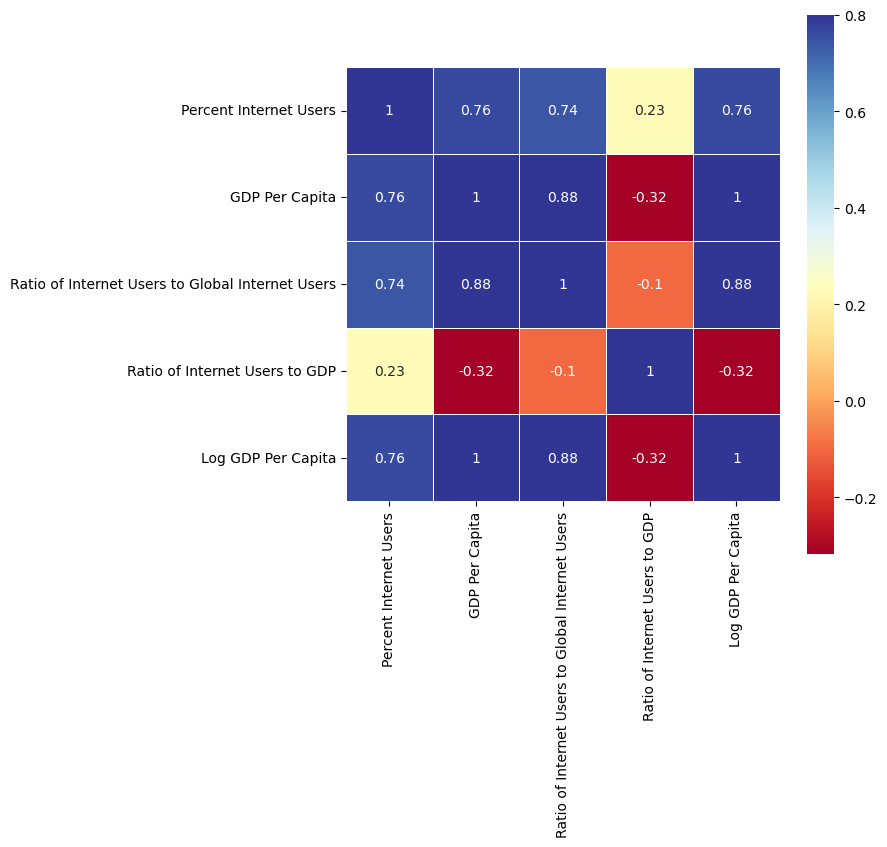

In [33]:
corr_df = combined_df[['Percent Internet Users', 'GDP Per Capita', 'Ratio of Internet Users to Global Internet Users', 'Ratio of Internet Users to GDP', 'Log GDP Per Capita']]
corrmat = corr_df.corr(method = 'spearman')
corrmat

f, ax = plt.subplots(figsize = (7,7))
sns.heatmap(corrmat, vmax = .8, square = True, annot = True, cmap = 'RdYlBu', linewidths = .5 )
plt.show()


Below, I created a new df called world_data with data from the entire world. I also created another df called regional_data, in which I took the median of data from each region for each year. Since my goal for this step is just to look at temporal trends in regional/global data, I filtered out the data for which the region is unknown, before combining the two df's. Lastly, because the rows that have a location of world also have a Region of 'Unknown', I replaced the value from Unknown to World. 

In [34]:
world_data = combined_df[combined_df["Location"] == "World"]
world_data.info()
regional_data = combined_df.groupby(['Region', 'Year']).median(numeric_only=True).reset_index()
regional_data.info()
regional_data = regional_data[regional_data["Region"] != "Unknown"]
regional_data.info()
regional_data = pd.concat([regional_data, world_data], axis=0)
regional_data.info()
regional_data.tail()
regional_data['Region'] = regional_data['Region'].replace({'Unknown': 'World'})
regional_data.head()
regional_data.tail()

<class 'pandas.core.frame.DataFrame'>
Index: 7 entries, 190 to 1349
Data columns (total 10 columns):
 #   Column                                            Non-Null Count  Dtype   
---  ------                                            --------------  -----   
 0   Year                                              7 non-null      int64   
 1   Location                                          7 non-null      object  
 2   Region                                            7 non-null      object  
 3   Percent Internet Users                            7 non-null      float64 
 4   GDP Per Capita                                    7 non-null      float64 
 5   Income Group                                      7 non-null      object  
 6   Internet Use Bins                                 7 non-null      category
 7   Ratio of Internet Users to Global Internet Users  7 non-null      float64 
 8   Ratio of Internet Users to GDP                    7 non-null      float64 
 9   Log GDP Per Ca

,Region,Year,Percent Internet Users,GDP Per Capita,Ratio of Internet Users to Global Internet Users,Ratio of Internet Users to GDP,Log GDP Per Capita,Location,Income Group,Internet Use Bins
591,Unknown,2010,28.5,9530.010809,1.0,0.002991,9.162201,World,Unknown,Low Internet Use
792,Unknown,2015,39.9,10175.409420,1.0,0.003921,9.227729,World,Unknown,Medium Internet Use
978,Unknown,2020,59.3,10963.175642,1.0,0.005409,9.302297,World,Unknown,Medium Internet Use
1165,Unknown,2021,62.2,12418.565925,1.0,0.005009,9.426948,World,Unknown,Medium Internet Use
1349,Unknown,2022,64.4,12819.744838,1.0,0.005024,9.458742,World,Unknown,Medium Internet Use


,Region,Year,Percent Internet Users,GDP Per Capita,Ratio of Internet Users to Global Internet Users,Ratio of Internet Users to GDP,Log GDP Per Capita,Location,Income Group,Internet Use Bins
0,East Asia & Pacific,2000,3.05,1995.720712,0.575472,0.001203,7.598761,NaN,NaN,NaN
1,East Asia & Pacific,2005,8.50,2550.042214,0.544872,0.002036,7.843865,NaN,NaN,NaN
2,East Asia & Pacific,2010,21.20,3432.614047,0.743860,0.002904,8.141066,NaN,NaN,NaN
3,East Asia & Pacific,2015,39.00,4104.132155,0.977444,0.006007,8.319738,NaN,NaN,NaN
4,East Asia & Pacific,2020,70.75,4910.266906,1.193086,0.012147,8.498994,NaN,NaN,NaN


,Region,Year,Percent Internet Users,GDP Per Capita,Ratio of Internet Users to Global Internet Users,Ratio of Internet Users to GDP,Log GDP Per Capita,Location,Income Group,Internet Use Bins
591,World,2010,28.5,9530.010809,1.0,0.002991,9.162201,World,Unknown,Low Internet Use
792,World,2015,39.9,10175.409420,1.0,0.003921,9.227729,World,Unknown,Medium Internet Use
978,World,2020,59.3,10963.175642,1.0,0.005409,9.302297,World,Unknown,Medium Internet Use
1165,World,2021,62.2,12418.565925,1.0,0.005009,9.426948,World,Unknown,Medium Internet Use
1349,World,2022,64.4,12819.744838,1.0,0.005024,9.458742,World,Unknown,Medium Internet Use


From these lineplots below, we can see how GDP Per Capita and Percent of Internet Users has changed over the years we are looking at. Here are some interesting observations that I had from this data:
- The rates of change of GDP Per Capita and Percent Internet Users are so different. It looks like the GDP Per Capita has remained relatively constant in much of the world from 2000-2022 with the exception of North America.
- Percent Internet Users has a bit more of an S-shaped curve, and there has been rapid adoption of the internet worldwide from 2000.

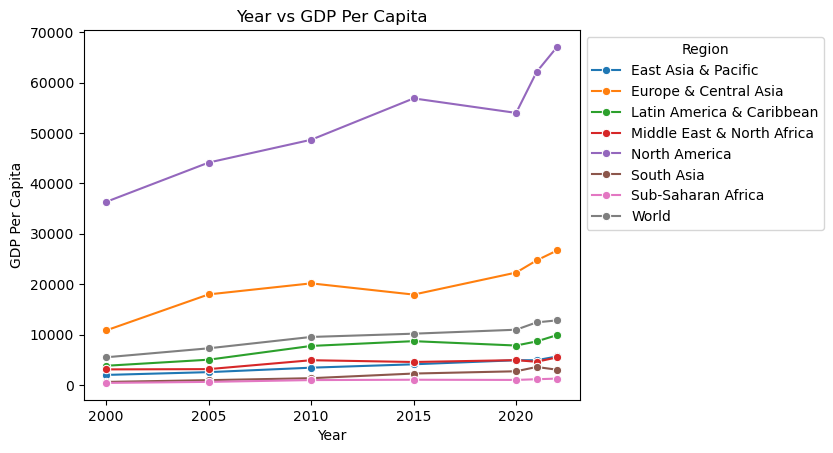

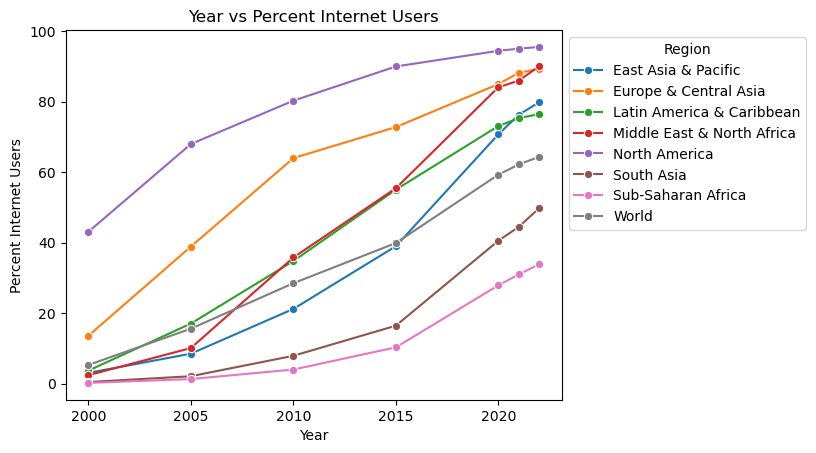

In [35]:
ax = sns.lineplot(data=regional_data, x='Year', y='GDP Per Capita', hue='Region', marker='o')
plt.title('Year vs GDP Per Capita')
plt.xlabel('Year')
plt.ylabel('GDP Per Capita')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.show();

ax = sns.lineplot(data=regional_data, x='Year', y='Percent Internet Users',hue='Region', marker='o')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.title('Year vs Percent Internet Users')
plt.xlabel('Year')
plt.ylabel('Percent Internet Users')
plt.show();

Here, we can see that there are only 3 locations being sampled the regional classification of North America in our data sample, which is likely why the GDP Per Capita data for North America is so much higher.

In [36]:
x = combined_df.loc[combined_df['Region'] == 'North America']
x["Location"].value_counts()

Location
Canada           7
United States    7
Bermuda          4
Name: count, dtype: int64

Here, I went ahead and made similar heatmaps for each of the indivudal years being studied. The heatmaps are presented in order of year from earliest to latest.  Here are some observations: 
- Each year being studied had a high positive correlation between GDP Per Capita and Percent Internet Usage, with the lowest correlation being 0.89.
- There weren't any differences b/w correlation scores for Log GDP Per Capita vs. those for GDP Per Capita.
- It's noteworthy that the overall correlation b/w GDP Per Capita and Percent Internet Usage from combined_df was 0.76, which is lower than that of each of the individual years. This makes sense since many years were being combined in combined_df.
- The correlation between the ratio of internet users to GDP and percent internet users gradually went from positive to strongly negative over the years. This makes a lot of sense. As countries became increasingly saturated in their percent of internet users, the GDP Per Capita increases outpaced the internet usage increases, leading to an inverse relationship between these two variables.
- The same trend was seen b/w the ratio of internet users to GDP and the GDP Per capita as well as b/w the ratio of internet users to GDP and Ratio of Internet Users to Global Internet Users. We can see that in earlier years, there was more rapid growth in internet usage than in GDP Per capita, but that changed overtime.

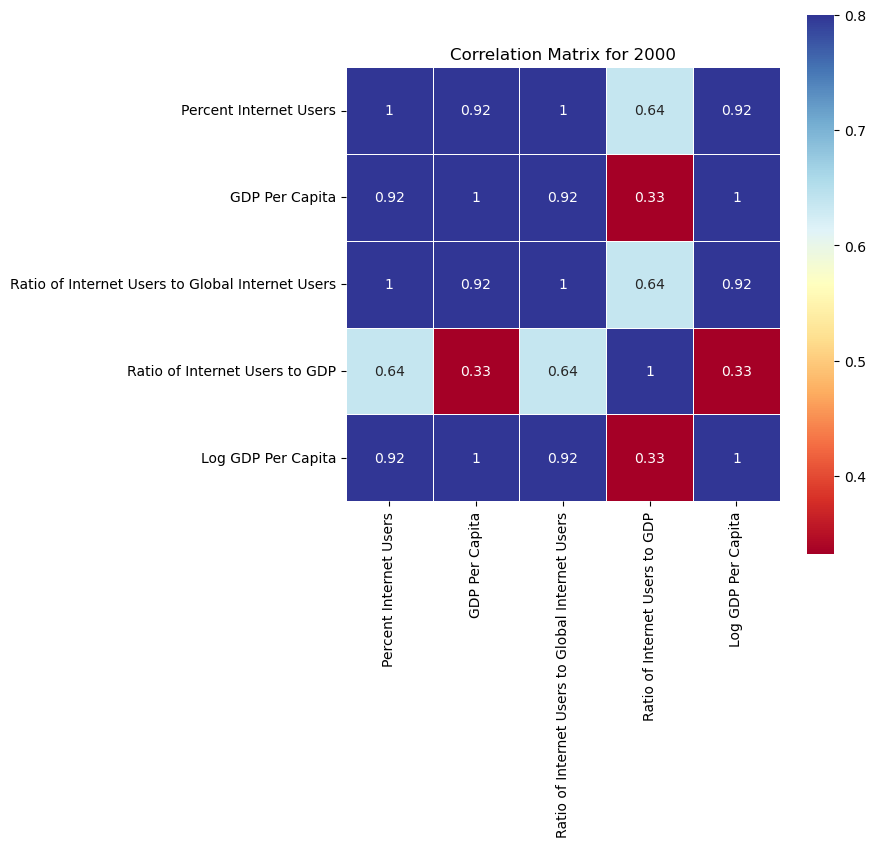

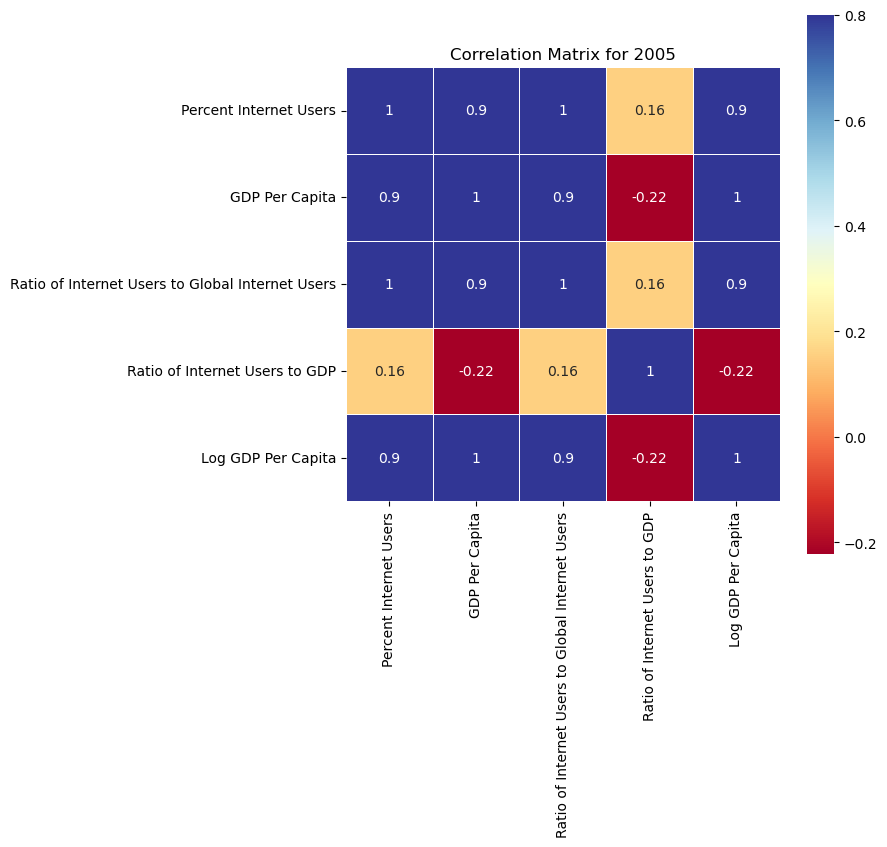

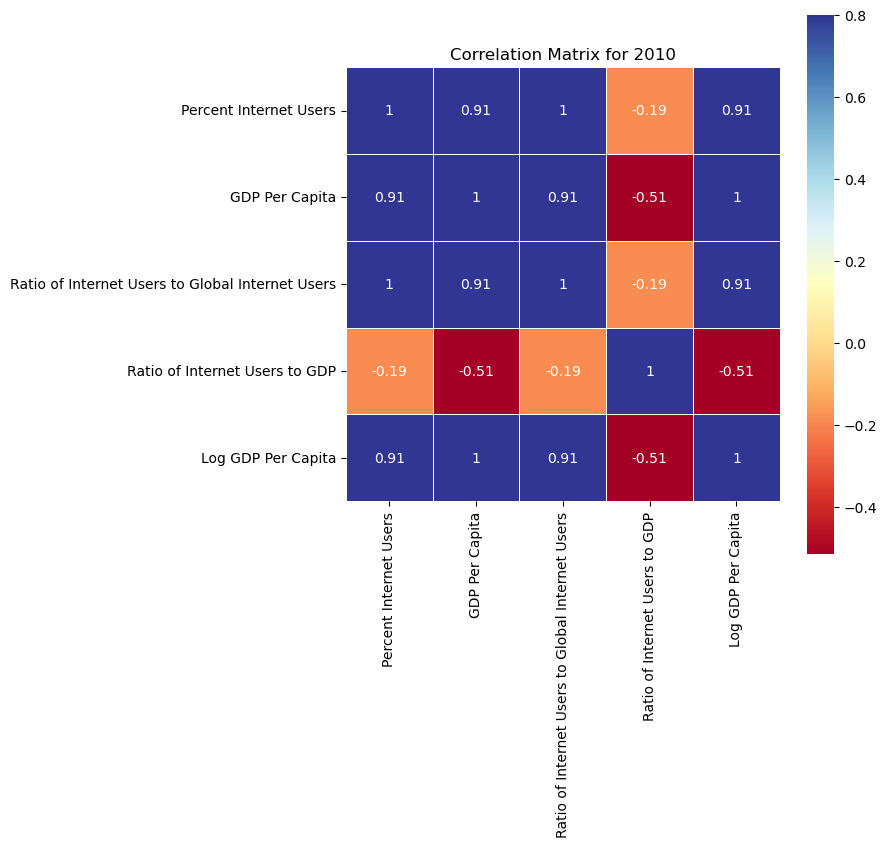

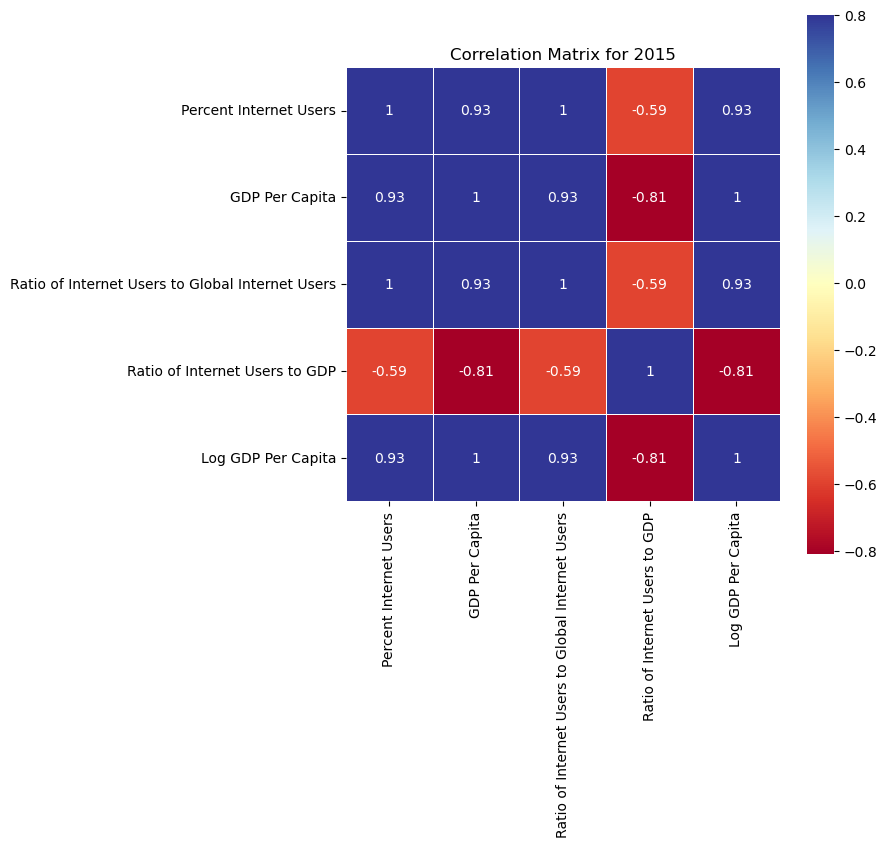

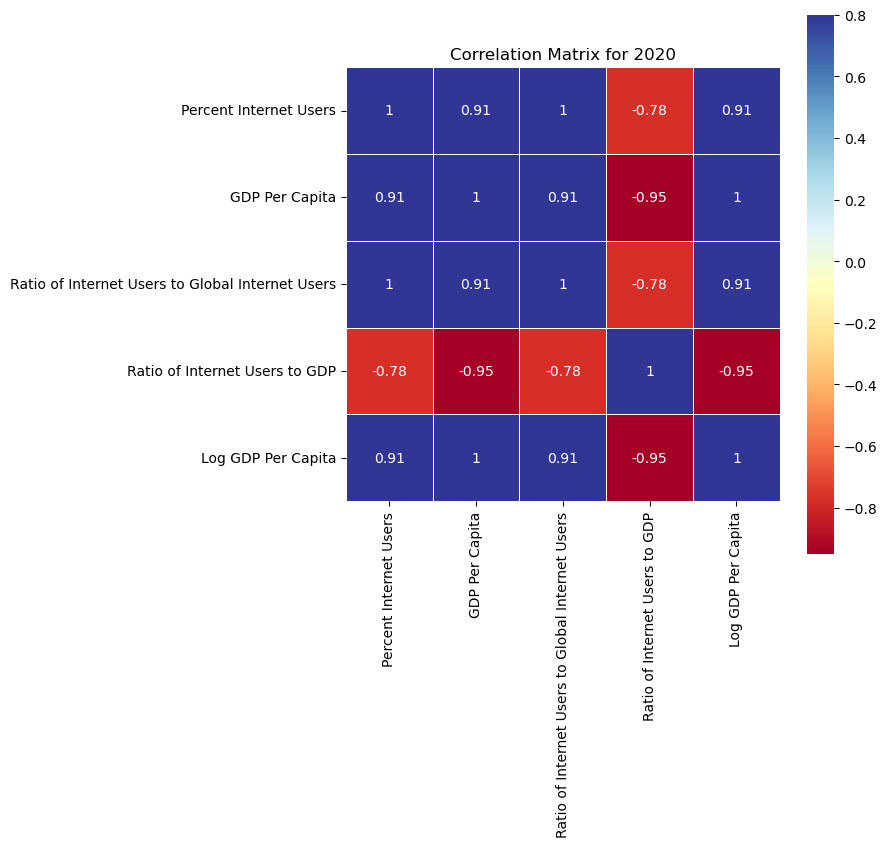

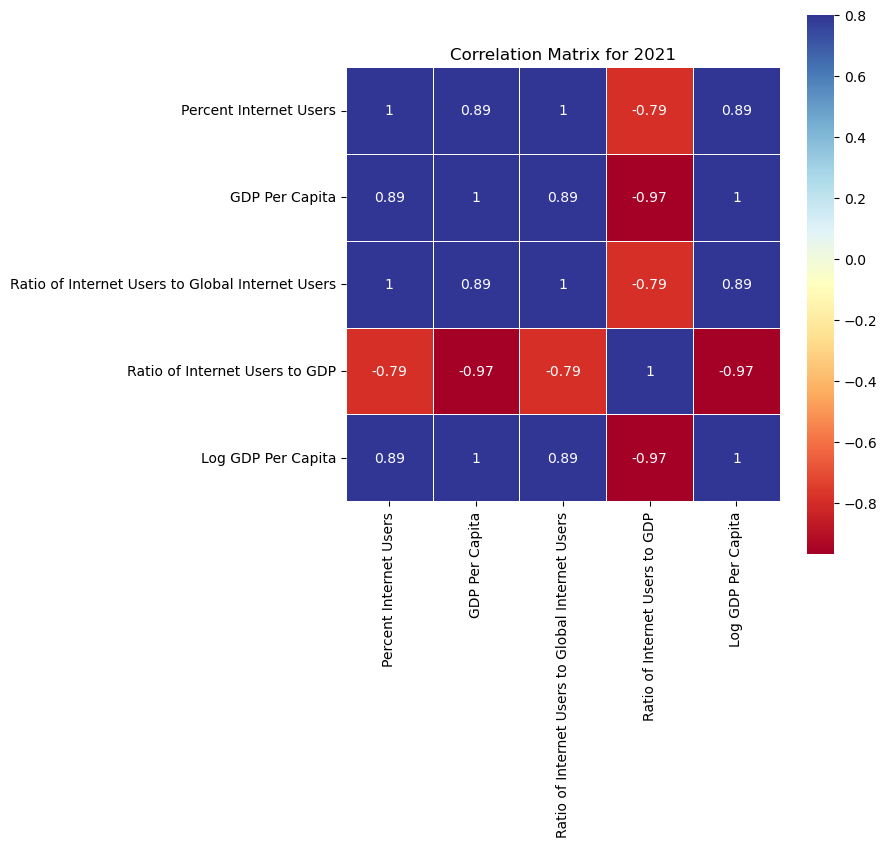

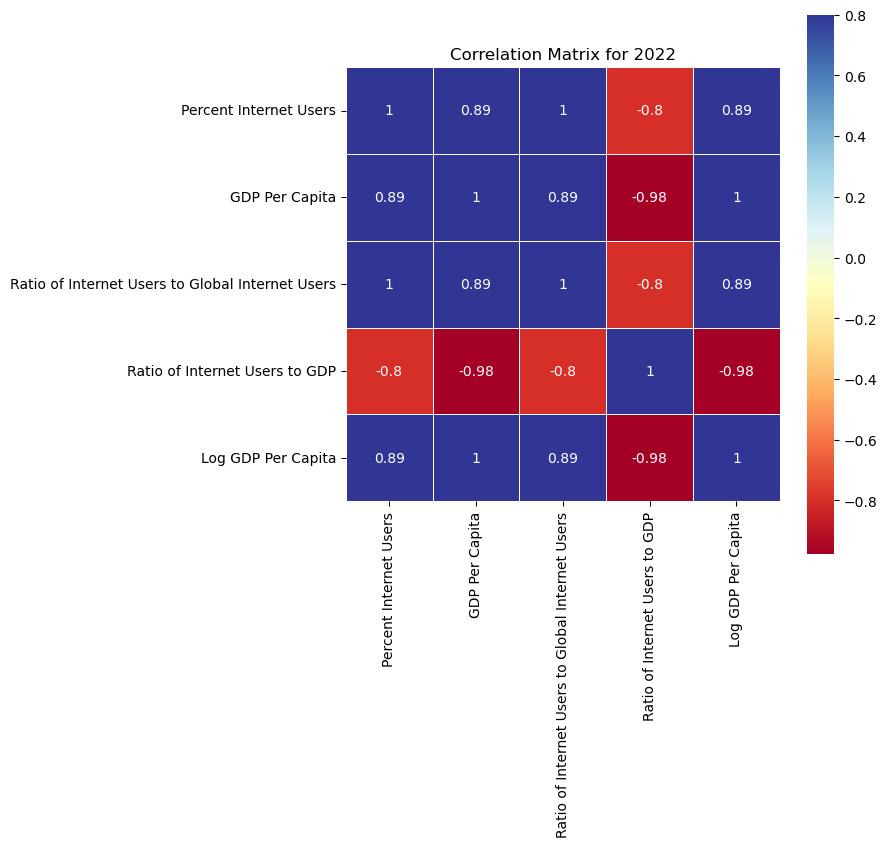

In [37]:
data_2000 = combined_df[combined_df["Year"] == 2000]
corr_df_2000 = data_2000[['Percent Internet Users', 'GDP Per Capita', 'Ratio of Internet Users to Global Internet Users', 'Ratio of Internet Users to GDP', 'Log GDP Per Capita']]
corrmat_1 = corr_df_2000.corr(method = 'spearman')


f, ax = plt.subplots(figsize = (7,7))
sns.heatmap(corrmat_1, vmax = .8, square = True, annot = True, cmap = 'RdYlBu', linewidths = .5 )
plt.title('Correlation Matrix for 2000')
plt.show();




data_2005 = combined_df[combined_df["Year"] == 2005]
corr_df_2005 = data_2005[['Percent Internet Users', 'GDP Per Capita', 'Ratio of Internet Users to Global Internet Users', 'Ratio of Internet Users to GDP', 'Log GDP Per Capita']]
corrmat_1 = corr_df_2005.corr(method = 'spearman')

f, ax = plt.subplots(figsize = (7,7))
sns.heatmap(corrmat_1, vmax = .8, square = True, annot = True, cmap = 'RdYlBu', linewidths = .5 )
plt.title('Correlation Matrix for 2005')
plt.show();



data_2010 = combined_df[combined_df["Year"] == 2010]
corr_df_2010 = data_2010[['Percent Internet Users', 'GDP Per Capita', 'Ratio of Internet Users to Global Internet Users', 'Ratio of Internet Users to GDP', 'Log GDP Per Capita']]
corrmat_1 = corr_df_2010.corr(method = 'spearman')


f, ax = plt.subplots(figsize = (7,7))
sns.heatmap(corrmat_1, vmax = .8, square = True, annot = True, cmap = 'RdYlBu', linewidths = .5 )
plt.title('Correlation Matrix for 2010')
plt.show();




data_2015 = combined_df[combined_df["Year"] == 2015]
corr_df_2015 = data_2015[['Percent Internet Users', 'GDP Per Capita', 'Ratio of Internet Users to Global Internet Users', 'Ratio of Internet Users to GDP', 'Log GDP Per Capita']]
corrmat_1 = corr_df_2015.corr(method = 'spearman')


f, ax = plt.subplots(figsize = (7,7))
sns.heatmap(corrmat_1, vmax = .8, square = True, annot = True, cmap = 'RdYlBu', linewidths = .5 )
plt.title('Correlation Matrix for 2015')
plt.show();



data_2020 = combined_df[combined_df["Year"] == 2020]
corr_df_2020 = data_2020[['Percent Internet Users', 'GDP Per Capita', 'Ratio of Internet Users to Global Internet Users', 'Ratio of Internet Users to GDP', 'Log GDP Per Capita']]
corrmat_1 = corr_df_2020.corr(method = 'spearman')


f, ax = plt.subplots(figsize = (7,7))
sns.heatmap(corrmat_1, vmax = .8, square = True, annot = True, cmap = 'RdYlBu', linewidths = .5 )
plt.title('Correlation Matrix for 2020')
plt.show();



data_2021 = combined_df[combined_df["Year"] == 2021]
corr_df_2021 = data_2021[['Percent Internet Users', 'GDP Per Capita', 'Ratio of Internet Users to Global Internet Users', 'Ratio of Internet Users to GDP', 'Log GDP Per Capita']]
corrmat_1 = corr_df_2021.corr(method = 'spearman')


f, ax = plt.subplots(figsize = (7,7))
sns.heatmap(corrmat_1, vmax = .8, square = True, annot = True, cmap = 'RdYlBu', linewidths = .5 )
plt.title('Correlation Matrix for 2021')
plt.show();



data_2022 = combined_df[combined_df["Year"] == 2022]
corr_df_2022 = data_2022[['Percent Internet Users', 'GDP Per Capita', 'Ratio of Internet Users to Global Internet Users', 'Ratio of Internet Users to GDP', 'Log GDP Per Capita']]
corrmat_1 = corr_df_2022.corr(method = 'spearman')


f, ax = plt.subplots(figsize = (7,7))
sns.heatmap(corrmat_1, vmax = .8, square = True, annot = True, cmap = 'RdYlBu', linewidths = .5 )
plt.title('Correlation Matrix for 2022')
plt.show();


Here, I made a df for each year filtering out locations with unknown income groups. 

In [38]:
data_2022 = combined_df[combined_df["Year"] == 2022]
data_2022.shape
data_2022 = data_2022[data_2022["Income Group"] != "Unknown"]
data_2022.shape

data_2021 = combined_df[combined_df["Year"] == 2021]
data_2021.shape
data_2021 = data_2021[data_2021["Income Group"] != "Unknown"]
data_2021.shape

data_2020 = combined_df[combined_df["Year"] == 2020]
data_2020.shape
data_2020 = data_2020[data_2020["Income Group"] != "Unknown"]
data_2020.shape


data_2015 = combined_df[combined_df["Year"] == 2015]
data_2015.shape
data_2015 = data_2015[data_2015["Income Group"] != "Unknown"]
data_2015.shape


data_2010 = combined_df[combined_df["Year"] == 2010]
data_2010.shape
data_2010 = data_2010[data_2010["Income Group"] != "Unknown"]
data_2010.shape


data_2005 = combined_df[combined_df["Year"] == 2005]
data_2005.shape
data_2005 = data_2005[data_2005["Income Group"] != "Unknown"]
data_2005.shape

data_2000.shape
data_2000 = data_2000[data_2000["Income Group"] != "Unknown"]
data_2000.shape





(184, 10)

(178, 10)

(187, 10)

(181, 10)

(186, 10)

...

(193, 10)

(200, 10)

(192, 10)

(196, 10)

(188, 10)

Here, I made violin plots for each year being studied, showing the percentage of internet users by location classified by income group. Here are some observations: 
- From 2000-2005, there's a massive amount of variation in internet usage amongst high income countries, and much lower amounts of variation shown in non-high income countries.
- In 2010 and 2015 we can see increases in internet usage accross all income groups, and a decrease in variation in internet usage in high income locations. There's also a large increase in the variation of internet usage in lower and upper middle locations during this time.
- After 2015, we begin to see a large lessening of variation amongst upper middle and high income locations, as their internet usage rates are quite high. The internet usage for low income locations still lags significantly, but has made major strides since 2000. 

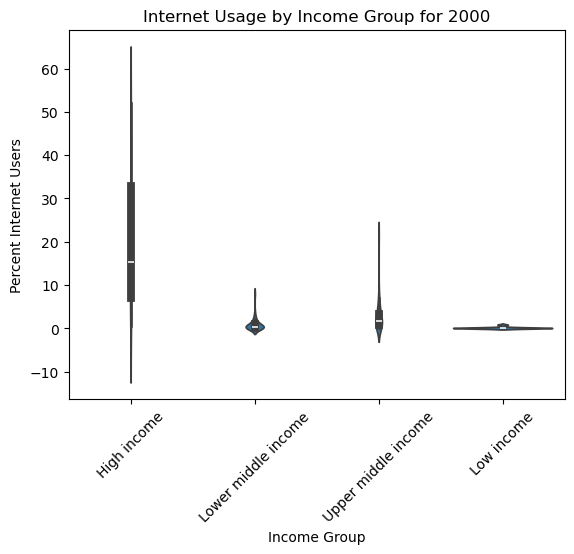

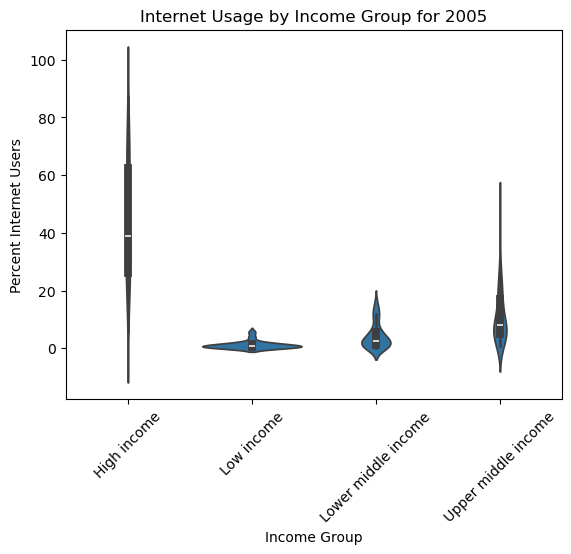

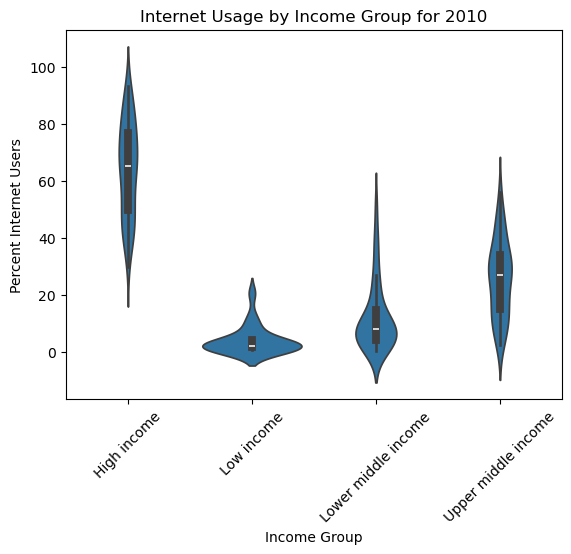

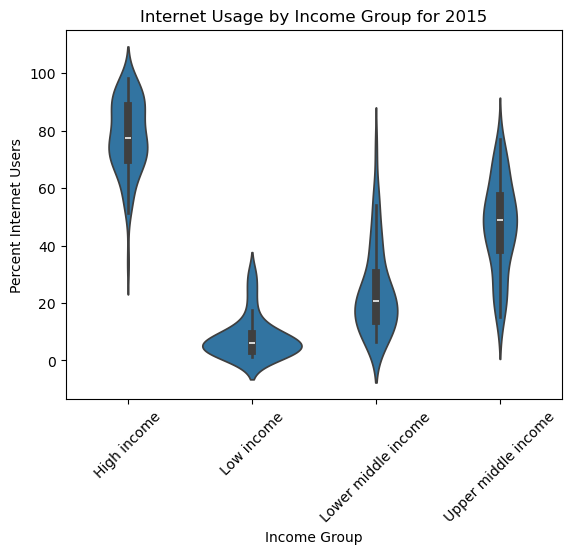

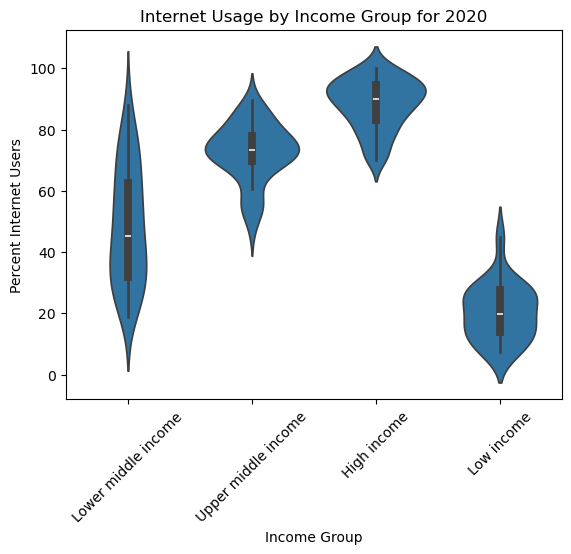

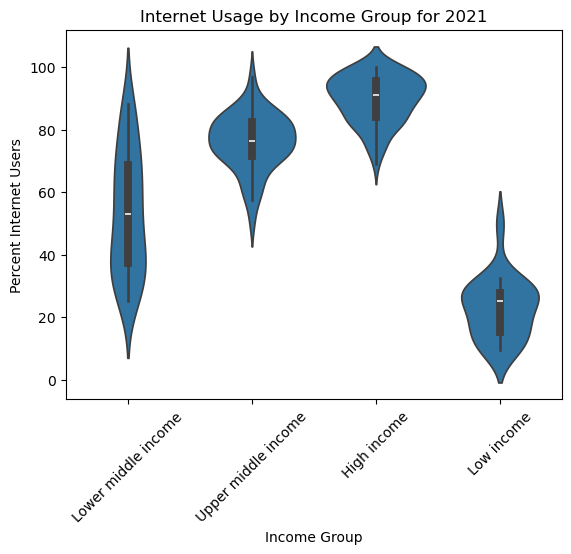

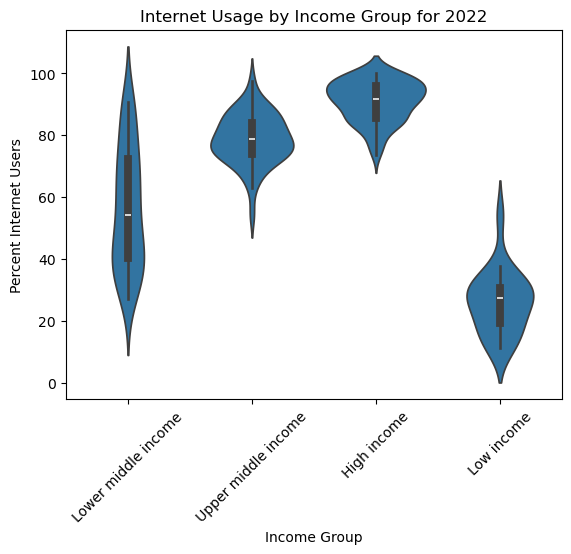

In [39]:
sns.violinplot(data=data_2000, x='Income Group', y='Percent Internet Users')
plt.title('Internet Usage by Income Group for 2000')
plt.xlabel('Income Group')
plt.ylabel('Percent Internet Users')
plt.xticks(rotation=45)
plt.show();

sns.violinplot(data=data_2005, x='Income Group', y='Percent Internet Users')
plt.title('Internet Usage by Income Group for 2005')
plt.xlabel('Income Group')
plt.ylabel('Percent Internet Users')
plt.xticks(rotation=45)
plt.show();

sns.violinplot(data=data_2010, x='Income Group', y='Percent Internet Users')
plt.title('Internet Usage by Income Group for 2010')
plt.xlabel('Income Group')
plt.ylabel('Percent Internet Users')
plt.xticks(rotation=45)
plt.show();

sns.violinplot(data=data_2015, x='Income Group', y='Percent Internet Users')
plt.title('Internet Usage by Income Group for 2015')
plt.xlabel('Income Group')
plt.ylabel('Percent Internet Users')
plt.xticks(rotation=45)
plt.show();

sns.violinplot(data=data_2020, x='Income Group', y='Percent Internet Users')
plt.title('Internet Usage by Income Group for 2020')
plt.xlabel('Income Group')
plt.ylabel('Percent Internet Users')
plt.xticks(rotation=45)
plt.show();

sns.violinplot(data=data_2021, x='Income Group', y='Percent Internet Users')
plt.title('Internet Usage by Income Group for 2021')
plt.xlabel('Income Group')
plt.ylabel('Percent Internet Users')
plt.xticks(rotation=45)
plt.show();

sns.violinplot(data=data_2022, x='Income Group', y='Percent Internet Users')
plt.title('Internet Usage by Income Group for 2022')
plt.xlabel('Income Group')
plt.ylabel('Percent Internet Users')
plt.xticks(rotation=45)
plt.show();


Below, I used the internet use bins to show the overall progression of internet usage accross all locations overtime. I used value_counts to see how many locations are present for each bin. This data shows us just how drastic the change is. 0 locations had high internet use and 170 had low internet use for 2000. This is almost flipped for 2022, with 124 locations with high internet use and only 22 locations with low internet use. 

In [40]:
data_2000["Internet Use Bins"].value_counts()
data_2005["Internet Use Bins"].value_counts()
data_2010["Internet Use Bins"].value_counts()
data_2015["Internet Use Bins"].value_counts()
data_2020["Internet Use Bins"].value_counts()
data_2021["Internet Use Bins"].value_counts()
data_2022["Internet Use Bins"].value_counts()


Internet Use Bins
Low Internet Use       170
Medium Internet Use     18
High Internet Use        0
Name: count, dtype: int64

Internet Use Bins
Low Internet Use       141
Medium Internet Use     36
High Internet Use       15
Name: count, dtype: int64

Internet Use Bins
Low Internet Use       102
Medium Internet Use     56
High Internet Use       35
Name: count, dtype: int64

Internet Use Bins
Low Internet Use       70
High Internet Use      68
Medium Internet Use    55
Name: count, dtype: int64

Internet Use Bins
High Internet Use      115
Medium Internet Use     33
Low Internet Use        32
Name: count, dtype: int64

Internet Use Bins
High Internet Use      120
Medium Internet Use     31
Low Internet Use        30
Name: count, dtype: int64

Internet Use Bins
High Internet Use      124
Medium Internet Use     32
Low Internet Use        22
Name: count, dtype: int64

Here, I made 4 separate scatterplots for percent internet users by GDP Per Capita for the years 2000 and 2005. Here are my observations: 
- There is a clear positive correlation that can be seen in each of the scatterplots.
- There is a significant amount of locations in the bottom left corner of the plots, indicating low exposure to the internet
- There are very few non high income locations that have greater than 20% internet use for both 2000 and 2005. In 2000, it looks like Malaysia is the only non-high income country that fits this.
- There was a clear progression in internet use observed from 2000 to 2005
- The countries with the highest percentage internet use are mostly Western Countries
- There is a more discernable linear relationship between the data with the log(GDP) scatterplots 

In [41]:


fig = px.scatter(data_2000,  x='Percent Internet Users', y='GDP Per Capita',
                 hover_name = 'Location', title='Percent Internet Users vs GDP Per Capita for 2000',
                 color_discrete_sequence = px.colors.qualitative.Bold, trendline="ols")
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'GDP Per Capita');
fig.show();


fig = px.scatter(data_2000,  x='Percent Internet Users', y='Log GDP Per Capita',
                 hover_name = 'Location', title='Percent Internet Users vs Log GDP Per Capita for 2000',
                 color_discrete_sequence = px.colors.qualitative.Bold, trendline="ols")
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'Log GDP Per Capita');
fig.show();



fig = px.scatter(data_2000,  x='Percent Internet Users', y='GDP Per Capita',
                 hover_name = 'Location', title='Percent Internet Users vs GDP Per Capita for 2000',
                 color_discrete_sequence = px.colors.qualitative.Bold, color = "Region")
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'GDP Per Capita');
fig.show();



fig = px.scatter(data_2000, x = "Percent Internet Users", y = "GDP Per Capita", color = 'Income Group', 
                 size_max = 60,
        title='Percent Internet Users vs GDP Per Capita for 2000', hover_name = 'Location',
                 color_discrete_sequence = px.colors.qualitative.Bold)
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'GDP Per Capita');
fig.show();

fig = px.scatter(data_2005,  x='Percent Internet Users', y='GDP Per Capita',
                 hover_name = 'Location', title='Percent Internet Users vs GDP Per Capita for 2005',
                 color_discrete_sequence = px.colors.qualitative.Bold, trendline="ols")
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'GDP Per Capita');
fig.show();


fig = px.scatter(data_2005,  x='Percent Internet Users', y='Log GDP Per Capita',
                 hover_name = 'Location', title='Percent Internet Users vs Log GDP Per Capita for 2005',
                 color_discrete_sequence = px.colors.qualitative.Bold, trendline="ols")
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'Log GDP Per Capita');
fig.show();



fig = px.scatter(data_2005,  x='Percent Internet Users', y='GDP Per Capita',
                 hover_name = 'Location', title='Percent Internet Users vs GDP Per Capita for 2005',
                 color_discrete_sequence = px.colors.qualitative.Bold, color = "Region")
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'GDP Per Capita');
fig.show();



fig = px.scatter(data_2005, x = "Percent Internet Users", y = "GDP Per Capita", color = 'Income Group', 
                 size_max = 60,
        title='Percent Internet Users vs GDP Per Capita for 2005', hover_name = 'Location',
                 color_discrete_sequence = px.colors.qualitative.Bold)
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'GDP Per Capita');
fig.show();



Here are some observations from the plots shown below: 
- There is a much stronger and clearer linear relationship between log(GDP Per Capita) and Percent Internet users in 2010 and 2015 than in earlier years.
- At this point, we can clearly start to see saturation in percent of internet users for many high income nations. For example, Iceland (high income nation) went from 93.4% to 98.2% internet users between 2010 and 2015. Meanwhile, South Africa (Upper middle income) went all the way from 24% to 51.9% in that same timespan.

In [42]:

fig = px.scatter(data_2010,  x='Percent Internet Users', y='GDP Per Capita',
                 hover_name = 'Location', title='Percent Internet Users vs GDP Per Capita for 2010',
                 color_discrete_sequence = px.colors.qualitative.Bold, trendline="ols")
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'GDP Per Capita');
fig.show();


fig = px.scatter(data_2010,  x='Percent Internet Users', y='Log GDP Per Capita',
                 hover_name = 'Location', title='Percent Internet Users vs Log GDP Per Capita for 2010',
                 color_discrete_sequence = px.colors.qualitative.Bold, trendline="ols")
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'Log GDP Per Capita');
fig.show();



fig = px.scatter(data_2010,  x='Percent Internet Users', y='GDP Per Capita',
                 hover_name = 'Location', title='Percent Internet Users vs GDP Per Capita for 2010',
                 color_discrete_sequence = px.colors.qualitative.Bold, color = "Region")
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'GDP Per Capita');
fig.show();


fig = px.scatter(data_2010, x = "Percent Internet Users", y = "GDP Per Capita", color = 'Income Group', 
                 size_max = 60,
        title='Percent Internet Users vs GDP Per Capita for 2010', hover_name = 'Location',
                 color_discrete_sequence = px.colors.qualitative.Bold)
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'GDP Per Capita');
fig.show();

fig = px.scatter(data_2015,  x='Percent Internet Users', y='GDP Per Capita',
                 hover_name = 'Location', title='Percent Internet Users vs GDP Per Capita for 2015',
                 color_discrete_sequence = px.colors.qualitative.Bold, trendline="ols")
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'GDP Per Capita');
fig.show();


fig = px.scatter(data_2015,  x='Percent Internet Users', y='Log GDP Per Capita',
                 hover_name = 'Location', title='Percent Internet Users vs Log GDP Per Capita for 2015',
                 color_discrete_sequence = px.colors.qualitative.Bold, trendline="ols")
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'Log GDP Per Capita');
fig.show();



fig = px.scatter(data_2015,  x='Percent Internet Users', y='GDP Per Capita',
                 hover_name = 'Location', title='Percent Internet Users vs GDP Per Capita for 2015',
                 color_discrete_sequence = px.colors.qualitative.Bold, color = "Region")
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'GDP Per Capita');
fig.show();



fig = px.scatter(data_2015, x = "Percent Internet Users", y = "GDP Per Capita", color = 'Income Group', 
                 size_max = 60,
        title='Percent Internet Users vs GDP Per Capita for 2015', hover_name = 'Location',
                 color_discrete_sequence = px.colors.qualitative.Bold)
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'GDP Per Capita');
fig.show();



Here are some of my observations from these plots from the 2020s:
- Although there is a clear, observeable positive correlation b/w GDP Per Capita/log(GDP Per Capita) and Percent Internet Users in all of these plots, we can see that the slope of the trendlines has gradually decreased over time. This indicates that changes to Percent Internet Users does not  equate to as large of a change in GDP Per Capita as it did before within our trendline equations. This is because by the 2020s, many countries already have between 80 and 100 percent internet users. The divide in internet usage is much lesser than it was ever before.
- It's interesting that Tajikistan has continued to lag behind greatly from other countries in the region titled 'Europe and Central Asia.' It has a GDP Per Capita of just 36.1 percent in 2022, which is very far behind the next country in the region, which is Armenia at 77 percent.
- We can see from the plots that by the 2020s, there are no longer only European or North American countries with internet users between 90 and 100%.


In [43]:


fig = px.scatter(data_2020,  x='Percent Internet Users', y='GDP Per Capita',
                 hover_name = 'Location', title='Percent Internet Users vs GDP Per Capita for 2020',
                 color_discrete_sequence = px.colors.qualitative.Bold, trendline="ols")
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'GDP Per Capita');
fig.show();


fig = px.scatter(data_2020,  x='Percent Internet Users', y='Log GDP Per Capita',
                 hover_name = 'Location', title='Percent Internet Users vs Log GDP Per Capita for 2020',
                 color_discrete_sequence = px.colors.qualitative.Bold, trendline="ols")
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'Log GDP Per Capita');
fig.show();



fig = px.scatter(data_2020,  x='Percent Internet Users', y='GDP Per Capita',
                 hover_name = 'Location', title='Percent Internet Users vs GDP Per Capita for 2020',
                 color_discrete_sequence = px.colors.qualitative.Bold, color = "Region")
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'GDP Per Capita');
fig.show();



fig = px.scatter(data_2020, x = "Percent Internet Users", y = "GDP Per Capita", color = 'Income Group', 
                 size_max = 60,
        title='Percent Internet Users vs GDP Per Capita for 2020', hover_name = 'Location',
                 color_discrete_sequence = px.colors.qualitative.Bold)
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'GDP Per Capita');
fig.show();





fig = px.scatter(data_2021,  x='Percent Internet Users', y='GDP Per Capita',
                 hover_name = 'Location', title='Percent Internet Users vs GDP Per Capita for 2021',
                 color_discrete_sequence = px.colors.qualitative.Bold, trendline="ols")
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'GDP Per Capita');
fig.show();


fig = px.scatter(data_2021,  x='Percent Internet Users', y='Log GDP Per Capita',
                 hover_name = 'Location', title='Percent Internet Users vs Log GDP Per Capita for 2021',
                 color_discrete_sequence = px.colors.qualitative.Bold, trendline="ols")
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'Log GDP Per Capita');
fig.show();



fig = px.scatter(data_2021,  x='Percent Internet Users', y='GDP Per Capita',
                 hover_name = 'Location', title='Percent Internet Users vs GDP Per Capita for 2021',
                 color_discrete_sequence = px.colors.qualitative.Bold, color = "Region")
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'GDP Per Capita');
fig.show();



fig = px.scatter(data_2021, x = "Percent Internet Users", y = "GDP Per Capita", color = 'Income Group', 
                 size_max = 60,
        title='Percent Internet Users vs GDP Per Capita for 2021', hover_name = 'Location',
                 color_discrete_sequence = px.colors.qualitative.Bold)
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'GDP Per Capita');
fig.show();






fig = px.scatter(data_2022,  x='Percent Internet Users', y='GDP Per Capita',
                 hover_name = 'Location', title='Percent Internet Users vs GDP Per Capita for 2022',
                 color_discrete_sequence = px.colors.qualitative.Bold, trendline="ols")
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'GDP Per Capita');
fig.show();


fig = px.scatter(data_2022,  x='Percent Internet Users', y='Log GDP Per Capita',
                 hover_name = 'Location', title='Percent Internet Users vs Log GDP Per Capita for 2022',
                 color_discrete_sequence = px.colors.qualitative.Bold, trendline="ols")
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'Log GDP Per Capita');
fig.show();



fig = px.scatter(data_2022,  x='Percent Internet Users', y='GDP Per Capita',
                 hover_name = 'Location', title='Percent Internet Users vs GDP Per Capita for 2022',
                 color_discrete_sequence = px.colors.qualitative.Bold, color = "Region")
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'GDP Per Capita');
fig.show();



fig = px.scatter(data_2022, x = "Percent Internet Users", y = "GDP Per Capita", color = 'Income Group', 
                 size_max = 60,
        title='Percent Internet Users vs GDP Per Capita for 2022', hover_name = 'Location',
                 color_discrete_sequence = px.colors.qualitative.Bold)
fig.update_layout(xaxis_title = 'Percent Internet Users',
                 yaxis_title = 'GDP Per Capita');
fig.show();

Overall Conclusions:
- GDP Per Capita and Percent of Internet Users were strongly positively correlated for each of the seven years being studied.
- In general, the GDP Per Capita increased quicker accross countries than the percent internet usage in later years of the study, while the opposite was observed for earlier years. 
- Overall, Sub-Saharan Africa has seen the slowest adoption of the internet out of all global regions, and Europe and Central Asia and North America have shown the quickest.
- The plots also show a clear relationship between income level of a location and percent internet users. The higher the level of income, in general, the higher the percent internet users is.